<a href="https://colab.research.google.com/github/AnuragTiwari-hub/AIML/blob/main/AIML6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving product_price_dataset.xls to product_price_dataset (1).xls


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:

df = pd.read_excel('product_price_dataset (1).xls')

print("First 5 rows of the dataset:")
print(df.head())
print("\nColumns in the dataset:")
print(df.columns)

target_column_name = 'Price'

if target_column_name in df.columns:
    X = df.drop(columns=[target_column_name])
    y = df[target_column_name]

    print("\nFeatures (X):")
    print(X.head())
    print("\nTarget to predict (y Target):")
    print(y.head())
else:
    print(f"\nError: Target column '{target_column_name}' not found in the dataset.")
    print("Please inspect the columns above and update 'target_column_name' accordingly.")

First 5 rows of the dataset:
   ProductID        ProductName      Brand       Category  Weight  \
0          1             Laptop   XYZ Corp        Laptops     2.5   
1          2         Smartphone    ABC Inc  Mobile Phones     0.2   
2          3         Headphones  SoundWave    Electronics     0.4   
3          4         Smartwatch   TechGuru  Wearable Tech     0.1   
4          5  Bluetooth Speaker  AudioKing  Audio Devices     1.0   

    Dimensions  Material   Color  Rating  NumReviews  Price  
0     13x9x0.7  Aluminum  Silver     4.5         120   1200  
1  5.7x2.8x0.3     Glass   Black     4.8         300    800  
2        8x7x2   Plastic   White     4.3          80    100  
3  1.5x1.5x0.4   Plastic   Black     4.6         150    250  
4        7x7x3     Metal     Red     4.2          50     80  

Columns in the dataset:
Index(['ProductID', 'ProductName', 'Brand', 'Category', 'Weight', 'Dimensions',
       'Material', 'Color', 'Rating', 'NumReviews', 'Price'],
      dtype='obje

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (96, 10)
Testing shape: (24, 10)


In [ ]:
regressor = LinearRegression()

categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

all_columns = list(set(X_train_encoded.columns) | set(X_test_encoded.columns))

X_train_aligned = X_train_encoded.reindex(columns=all_columns, fill_value=0)
X_test_aligned = X_test_encoded.reindex(columns=all_columns, fill_value=0)

X_train_aligned = X_train_aligned.sort_index(axis=1)
X_test_aligned = X_test_aligned.sort_index(axis=1)

regressor.fit(X_train_aligned, y_train)

print("Regression model training completed.")

Regression model training completed.


In [ ]:
# Predict on the test set using the aligned and encoded test data
y_pred = regressor.predict(X_test_aligned)

# Calculate error metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 41865.3851
R-squared Score: 0.2022


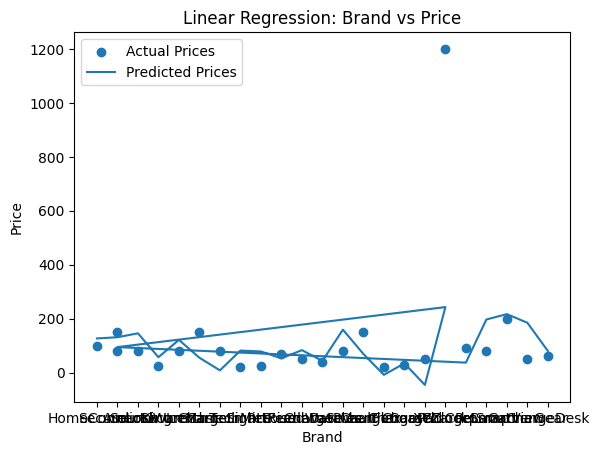

In [ ]:
import matplotlib.pyplot as plt

model = LinearRegression()

model.fit(X_train_aligned, y_train)

y_pred = model.predict(X_test_aligned)

plt.figure()

plt.scatter(X_test['Brand'], y_test, label='Actual Prices')
plt.plot(X_test['Brand'], y_pred,  label='Predicted Prices')
plt.xlabel("Brand")
plt.ylabel("Price")
plt.title("Linear Regression: Brand vs Price")
plt.legend()
plt.show()